# Bài tập 3.26 – 3.30: Gradient Descent & Perceptron

## 3.26 Gradient Descent cho $f(x)=x^2-4x+5$
**1. Đạo hàm:** $f'(x)=2x-4$

**Cập nhật:** $x_{t+1}=x_t-\eta f'(x_t)=x_t-0.2(2x_t-4)$, tức $x_{t+1}-2 = 0.6\,(x_t-2)$.

In [1]:
import numpy as np
f  = lambda x: x**2 - 4*x + 5
df = lambda x: 2*x - 4

x, eta = 5.0, 0.2
print(f"{'t':>2} | {'x_t':>9} | {'f\'(x_t)':>9} | {'f(x_t)':>9}")
print(f"{0:>2} | {x:9.4f} | {df(x):9.4f} | {f(x):9.4f}")
xs=[x]
for t in range(1,5):
    x = x - eta*df(x); xs.append(x)
    print(f"{t:>2} | {x:9.4f} | {df(x):9.4f} | {f(x):9.4f}")

 t |       x_t |   f'(x_t) |    f(x_t)
 0 |    5.0000 |    6.0000 |   10.0000
 1 |    3.8000 |    3.6000 |    4.2400
 2 |    3.0800 |    2.1600 |    2.1664
 3 |    2.6480 |    1.2960 |    1.4199
 4 |    2.3888 |    0.7776 |    1.1512


**Kết quả:** x = 5 → 3.8 → 3.08 → 2.648 → 2.3888; f = 10 → 4.24 → 2.1664 → 1.4199 → 1.1512.

**Nhận xét:** f giảm đơn điệu, x tiến về cực tiểu $x^*=2$, $f(x^*)=1$. Sai số $|x_t-2|$ giảm theo cấp số nhân với hệ số $|1-2\eta|=0.6<1$ nên hội tụ tuyến tính; gradient nhỏ dần nên bước cập nhật cũng nhỏ dần. Hàm lồi nên cực tiểu cục bộ cũng là toàn cục.

## 3.27 Perceptron: $w=[1,2,-10]^T$, $x=[3,4,1]^T$

In [2]:
w = np.array([1,2,-10]); x = np.array([3,4,1])
s = w @ x
print("w^T x =", s)
print("Nhãn dự đoán =", 1 if s>=0 else -1)
y = -1
print("y * w^T x =", y*s, "-> bị phân lớp sai" if y*s<=0 else "-> đúng")

w^T x = 1
Nhãn dự đoán = 1
y * w^T x = -1 -> bị phân lớp sai


1. $w^Tx = 3+8-10 = 1$
2. $w^Tx>0$ ⇒ nhãn dự đoán $=+1$
3. Nhãn thực $y=-1\neq +1$ (hay $y\,w^Tx=-1<0$) ⇒ **bị phân lớp sai**.

## 3.28 Perceptron: $w=[-2,1,0]^T$, $x=[2,3,1]^T$, $y=1$

In [3]:
w = np.array([-2,1,0]); x = np.array([2,3,1]); y = 1
s = w @ x
print("w^T x =", s, "| dự đoán:", 1 if s>=0 else -1, "| sai?", y*s<=0)
if y*s <= 0:
    w_new = w + y*x
    print("w mới =", w_new)
    print("w_new^T x =", w_new @ x)

w^T x = -1 | dự đoán: -1 | sai? True
w mới = [0 4 1]
w_new^T x = 13


1. $w^Tx=-4+3+0=-1<0$ ⇒ dự đoán $-1\neq y=1$ ⇒ **sai**.
2. Cập nhật: $w_{new}=w+yx=[-2,1,0]+[2,3,1]=[0,4,1]^T$.
3. $w_{new}^Tx=0+12+1=13>0$ ⇒ mẫu đã được phân lớp đúng.

## 3.29 Lớp Perceptron (fit / predict)

In [4]:
class Perceptron:
    """Perceptron nhị phân, nhãn {-1, +1}. Có tùy chọn pocket (giữ w tốt nhất)."""
    def __init__(self, lr=1.0, max_epochs=100, pocket=True, shuffle=True, random_state=0):
        self.lr, self.max_epochs = lr, max_epochs
        self.pocket, self.shuffle = pocket, shuffle
        self.rng = np.random.default_rng(random_state)

    @staticmethod
    def _add_bias(X):
        return np.hstack([X, np.ones((X.shape[0], 1))])

    def fit(self, X, y):
        y = np.where(np.asarray(y) > 0, 1, -1)
        Xb = self._add_bias(np.asarray(X, float))
        n, d = Xb.shape
        w = np.zeros(d)
        best_w, best_err = w.copy(), n
        self.errors_ = []
        for _ in range(self.max_epochs):
            idx = self.rng.permutation(n) if self.shuffle else np.arange(n)
            for i in idx:
                if y[i] * (Xb[i] @ w) <= 0:      # phân lớp sai
                    w = w + self.lr * y[i] * Xb[i]
                    if self.pocket:
                        err = np.sum(np.sign(Xb @ w + 1e-12) != y)
                        if err < best_err:
                            best_w, best_err = w.copy(), err
            err = np.sum(np.where(Xb @ w >= 0, 1, -1) != y)
            self.errors_.append(err)
            if err == 0:
                best_w = w.copy(); break
        self.w_ = best_w if self.pocket else w
        return self

    def decision_function(self, X):
        return self._add_bias(np.asarray(X, float)) @ self.w_

    def predict(self, X):
        return np.where(self.decision_function(X) >= 0, 1, -1)

# Kiểm thử nhanh trên dữ liệu tách được tuyến tính
rng = np.random.default_rng(1)
X = np.vstack([rng.normal([2,2],0.5,(50,2)), rng.normal([-2,-2],0.5,(50,2))])
y = np.array([1]*50 + [-1]*50)
m = Perceptron().fit(X, y)
print("w =", m.w_, "| accuracy =", (m.predict(X)==y).mean())

w = [ 1.64992412  1.66817121 -1.        ] | accuracy = 1.0


## 3.30 Phân lớp nhị phân bằng Perceptron
Notebook này **chỉ cần numpy** (không cần sklearn/pandas). Dữ liệu: nếu máy có sklearn thì dùng *Breast Cancer Wisconsin* (ác tính = +1); nếu không thì tự sinh dữ liệu giả lập kiểu giao dịch gian lận (mất cân bằng, ~10% gian lận).

Quy trình: chia train/val/test → chuẩn hóa (fit trên train) → chọn siêu tham số theo F1 trên validation → đánh giá cuối trên test.

In [5]:
import itertools

def load_data():
    try:
        from sklearn.datasets import load_breast_cancer
        d = load_breast_cancer()
        return d.data, np.where(d.target==0, 1, -1), "Breast Cancer Wisconsin"
    except ImportError:
        rng = np.random.default_rng(42)
        n, n_fraud, d = 3000, 300, 10
        A = rng.normal(size=(d, d))                       # tạo tương quan giữa các đặc trưng
        Xn = rng.normal(size=(n-n_fraud, d)) @ A
        Xf = rng.normal(size=(n_fraud, d)) @ A + rng.normal(0.35, 0.1, d)   # gian lận lệch trung bình
        X = np.vstack([Xn, Xf]); y = np.array([-1]*(n-n_fraud) + [1]*n_fraud)
        return X, y, "Dữ liệu giao dịch gian lận giả lập"

def stratified_split(X, y, test_size, seed):
    rng = np.random.default_rng(seed)
    te = []
    for c in np.unique(y):
        idx = rng.permutation(np.where(y==c)[0])
        te += list(idx[:int(round(len(idx)*test_size))])
    te = np.array(te); tr = np.setdiff1d(np.arange(len(y)), te)
    return X[tr], X[te], y[tr], y[te]

def metrics(y_true, y_pred):
    tp = np.sum((y_true==1)&(y_pred==1)); tn = np.sum((y_true==-1)&(y_pred==-1))
    fp = np.sum((y_true==-1)&(y_pred==1)); fn = np.sum((y_true==1)&(y_pred==-1))
    acc = (tp+tn)/len(y_true)
    prec = tp/(tp+fp) if tp+fp else 0.0
    rec = tp/(tp+fn) if tp+fn else 0.0
    f1 = 2*prec*rec/(prec+rec) if prec+rec else 0.0
    return dict(acc=acc, prec=prec, rec=rec, f1=f1), np.array([[tn,fp],[fn,tp]])

X, y, name = load_data()
print("Dữ liệu:", name, "| kích thước:", X.shape, "| tỉ lệ dương:", round((y==1).mean(),3))

X_tmp, X_test, y_tmp, y_test = stratified_split(X, y, 0.2, 42)
X_train, X_val, y_train, y_val = stratified_split(X_tmp, y_tmp, 0.25, 42)

mu, sd = X_train.mean(0), X_train.std(0) + 1e-12       # chuẩn hóa theo train
X_train, X_val, X_test = [(A-mu)/sd for A in (X_train, X_val, X_test)]

Dữ liệu: Dữ liệu giao dịch gian lận giả lập | kích thước: (3000, 10) | tỉ lệ dương: 0.1


In [6]:
rows=[]
for lr, ep, pk in itertools.product([0.01,0.1,1.0],[50,200,500],[False,True]):
    m = Perceptron(lr=lr, max_epochs=ep, pocket=pk, random_state=0).fit(X_train, y_train)
    r,_ = metrics(y_val, m.predict(X_val))
    rows.append(dict(lr=lr, epochs=ep, pocket=pk, **r))
rows.sort(key=lambda r:(r['f1'], r['acc']), reverse=True)

print(f"{'lr':>5} {'epochs':>6} {'pocket':>6} | {'acc':>6} {'prec':>6} {'rec':>6} {'f1':>6}")
for r in rows[:8]:
    print(f"{r['lr']:>5} {r['epochs']:>6} {str(r['pocket']):>6} | {r['acc']:6.4f} {r['prec']:6.4f} {r['rec']:6.4f} {r['f1']:6.4f}")

   lr epochs pocket |    acc   prec    rec     f1
 0.01     50  False | 1.0000 1.0000 1.0000 1.0000
 0.01    500  False | 1.0000 1.0000 1.0000 1.0000
  0.1     50  False | 1.0000 1.0000 1.0000 1.0000
  0.1    500  False | 1.0000 1.0000 1.0000 1.0000
  1.0     50  False | 1.0000 1.0000 1.0000 1.0000
  1.0    500  False | 1.0000 1.0000 1.0000 1.0000
 0.01    200   True | 0.9983 0.9836 1.0000 0.9917
 0.01    500   True | 0.9983 0.9836 1.0000 0.9917


In [7]:
best = rows[0]
print("Siêu tham số tốt nhất:", {k:best[k] for k in ('lr','epochs','pocket')})

Xtv, ytv = np.vstack([X_train, X_val]), np.concatenate([y_train, y_val])
model = Perceptron(lr=best['lr'], max_epochs=best['epochs'], pocket=best['pocket'], random_state=0).fit(Xtv, ytv)
r, cm = metrics(y_test, model.predict(X_test))

print(f"Accuracy : {r['acc']:.4f}")
print(f"Precision: {r['prec']:.4f}")
print(f"Recall   : {r['rec']:.4f}")
print(f"F1-score : {r['f1']:.4f}")
print("Ma trận nhầm lẫn [[TN FP],[FN TP]]:")
print(cm)

Siêu tham số tốt nhất: {'lr': 0.01, 'epochs': 50, 'pocket': False}
Accuracy : 0.9967
Precision: 0.9833
Recall   : 0.9833
F1-score : 0.9833
Ma trận nhầm lẫn [[TN FP],[FN TP]]:
[[539   1]
 [  1  59]]


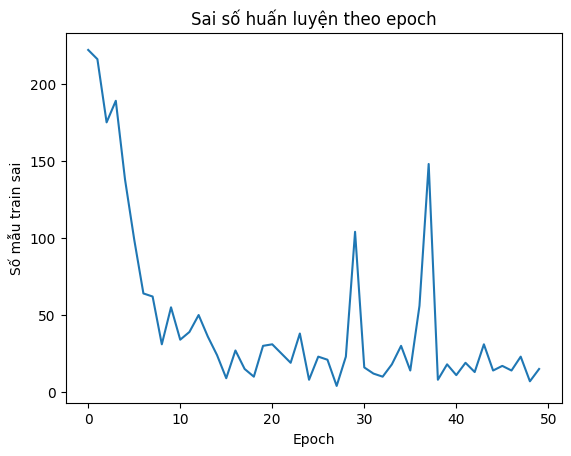

In [8]:
try:
    import matplotlib.pyplot as plt
    plt.plot(model.errors_); plt.xlabel("Epoch"); plt.ylabel("Số mẫu train sai")
    plt.title("Sai số huấn luyện theo epoch"); plt.show()
except ImportError:
    print("Không có matplotlib, bỏ qua biểu đồ.")

**Nhận xét:** Perceptron chỉ hội tụ hoàn toàn khi dữ liệu tách được tuyến tính; với dữ liệu thực thường không, nên dùng *pocket* (giữ w tốt nhất) cho kết quả ổn định hơn. Chuẩn hóa đặc trưng là bước quan trọng. Với bài toán gian lận/y tế, cần ưu tiên **Recall** vì bỏ sót ca dương nghiêm trọng hơn báo nhầm.